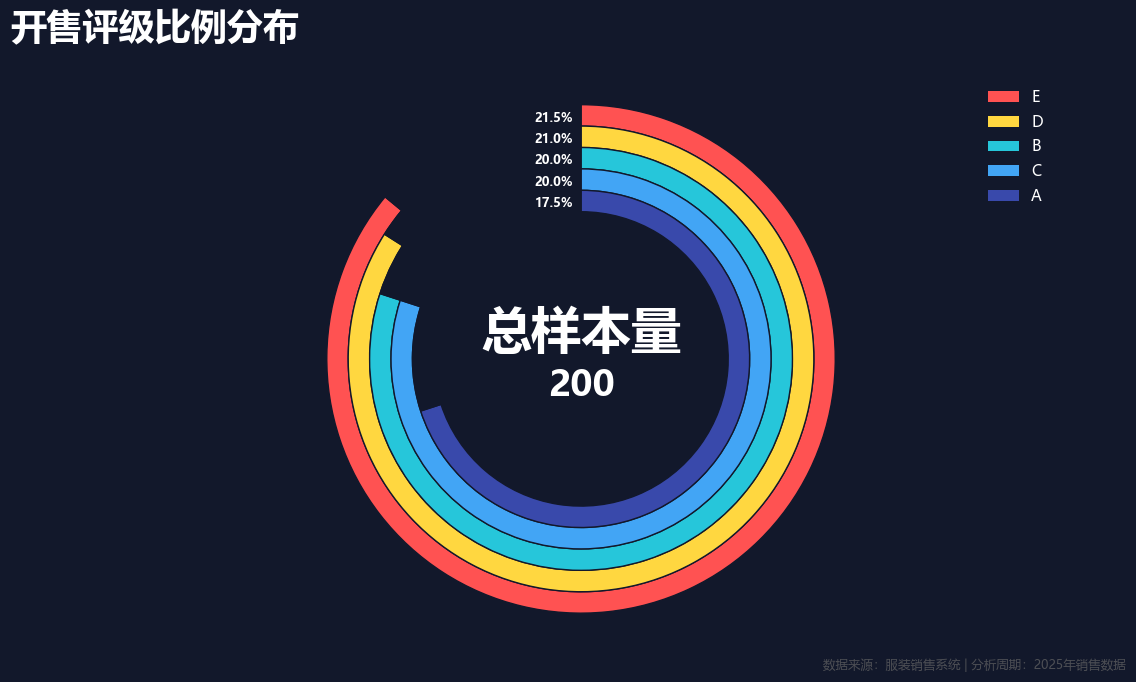

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据
    df = pd.read_csv('../../spu_manages_feishu.csv', encoding='utf-8-sig')

    # 统计开售评级比例
    rating_counts = df['开售评级'].value_counts()
    total = int(len(df) / 4)

    # 评级固定顺序
    ordered_ratings = ['A', 'B', 'C', 'D', 'E']

    # 计算百分比（缺失的按0处理），并保留1位小数用于展示
    ratios = {r: rating_counts.get(r, 0) / total for r in ordered_ratings}
    percentages_map = {r: round(ratios[r] * 100, 1) for r in ordered_ratings}

    # 将评级按占比从大到小排序，用于环的位置映射
    ranked_ratings_desc = sorted(
        ordered_ratings,
        key=lambda r: (-percentages_map[r], ordered_ratings.index(r))
    )

    # 固定颜色（外→内）
    BACKGROUND_COLOR = "#12182B"
    COLORS = ["#FF5252", "#FFD740", "#26C6DA", "#42A5F5", "#3949AB"]  # 外到内颜色不变

    # 创建图形
    plt.figure(figsize=(12, 7), facecolor=BACKGROUND_COLOR)
    ax = plt.gca()
    ax.set_facecolor(BACKGROUND_COLOR)

    # 创建5层环形
    width = 0.08
    center = (0.5, 0.5)
    outer_radius = 0.95

    start_angle = 90  # 所有圆环的起始角度相同

    # 用于垂直排列标签的参数
    label_x = -0.03  # 所有标签的x坐标（左侧）
    label_y_base = 0.9  # 起始y坐标
    label_spacing = 0.08  # 标签垂直间距

    for i in range(5):
        rating = ranked_ratings_desc[i]
        perc   = percentages_map[rating]
        radius = outer_radius - i * width
        ax.pie(
            [perc, 100 - perc],
            radius=radius,
            colors=[COLORS[i], BACKGROUND_COLOR],   # 圈色固定：0→最外，4→最内
            startangle=start_angle,
            counterclock=False,
            wedgeprops={'width': width, 'edgecolor': BACKGROUND_COLOR}
        )

        # 计算标签位置 - 统一放在圆心左侧垂直线上
        if perc > 0:
            # 计算当前标签的垂直位置（从上到下排列）
            y_pos = label_y_base - i * label_spacing
            
            plt.text(
                label_x, y_pos,
                f"{perc/4}%",
                ha='right',  # 右对齐，使文本右侧对齐在x=-0.7
                va='center',
                color='white',
                fontsize=9,  # 适当增大字号
                fontweight='bold'
            )

    # 标题与中心信息
    plt.figtext(0.02, 0.95, "开售评级比例分布",
                ha='left', fontsize=26, color='#ffffff', fontweight='bold')

    plt.text(0, 0.09, '总样本量',
             ha='center', va='center', color='#ffffff', fontsize=36, fontweight='bold')

    plt.text(0, -0.1, str(total*4),
             ha='center', va='center', color='#ffffff', fontsize=26, fontweight='bold')

    # 创建图例：按A-E顺序，仅显示评级，不显示百分比
    legend_patches = [
        Patch(facecolor=COLORS[i], label=ranked_ratings_desc[i])  # i=0 最外圈
        for i in range(5)
    ]

    ax.legend(handles=legend_patches,
              loc='upper right',
              bbox_to_anchor=(0.99, 1.2),
              frameon=False,
              labelcolor='#ffffff',
              fontsize=11)

    # 坐标轴与外观
    ax.set_xlim(-0.5, 1.8)
    ax.set_ylim(-0.5, 0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(False)

    # 数据来源
    plt.figtext(0.95, 0.05,
                '数据来源：服装销售系统 | 分析周期：2025年销售数据',
                ha='right', fontsize=9, color='#666666', alpha=0.7)

    # 调整布局
    plt.tight_layout(rect=(0.13, 0.03, 1, 0.95))

    plt.savefig('开售评级比例分布.png', dpi=300, facecolor=BACKGROUND_COLOR, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 数据分析

  - **A级**（深蓝色）：占比最低，表明在样本中，A级评级的样本数量最少，可能反映了较低的客户满意度或产品质量。

  - **B级**（浅蓝色）：占比略高于A级，显示出一定数量的样本获得了B级评级。

  - **C级**（青色）：比例适中，表明部分样本获得了中等评级。

  - **D级**（黄色）：比例较高，显示出较多样本获得了D级评级。
  
  - **E级**（红色）：占比最高，表明在样本中，E级评级的样本数量最多，可能反映了客户满意度或产品质量方面存在较多问题。


# 结论

从开售评级比例分布来看，E级评级占据了较大比例，显示出大部分样本在客户满意度或产品质量方面表现不佳。A级和B级评级的比例较低，表明优秀评级的样本数量较少。这种分布可能指示需要对产品或服务进行改进，以提高客户满意度和产品质量。